Total samples found: 2781


Exploring Dataset:   0%|                                                   | 0/2781 [00:00<?, ?it/s]

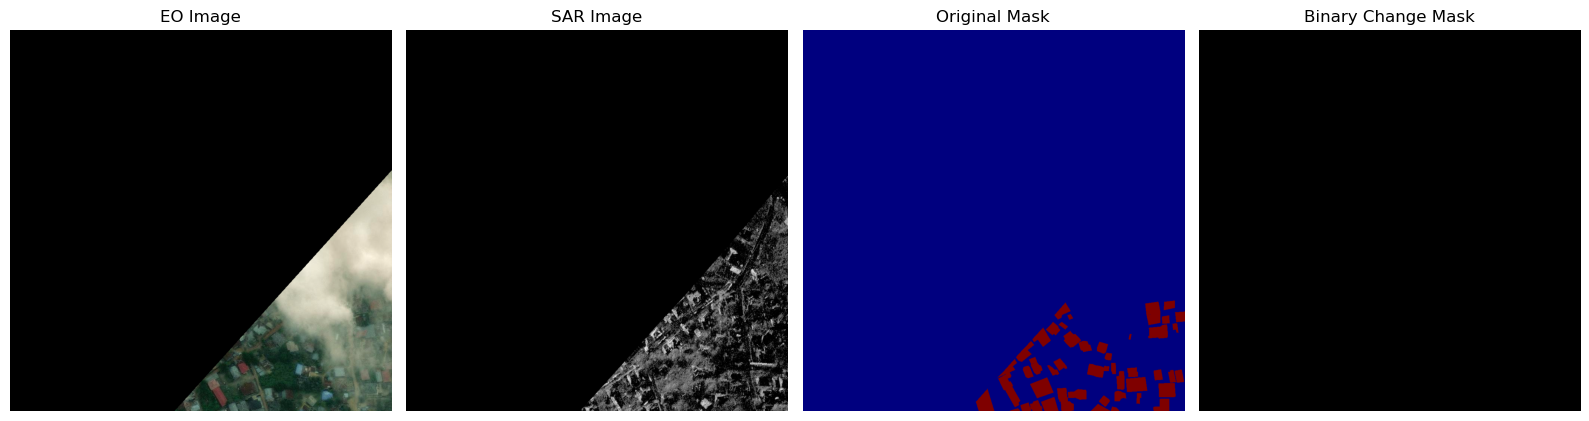

Exploring Dataset:   0%|                                           | 1/2781 [00:00<19:17,  2.40it/s]

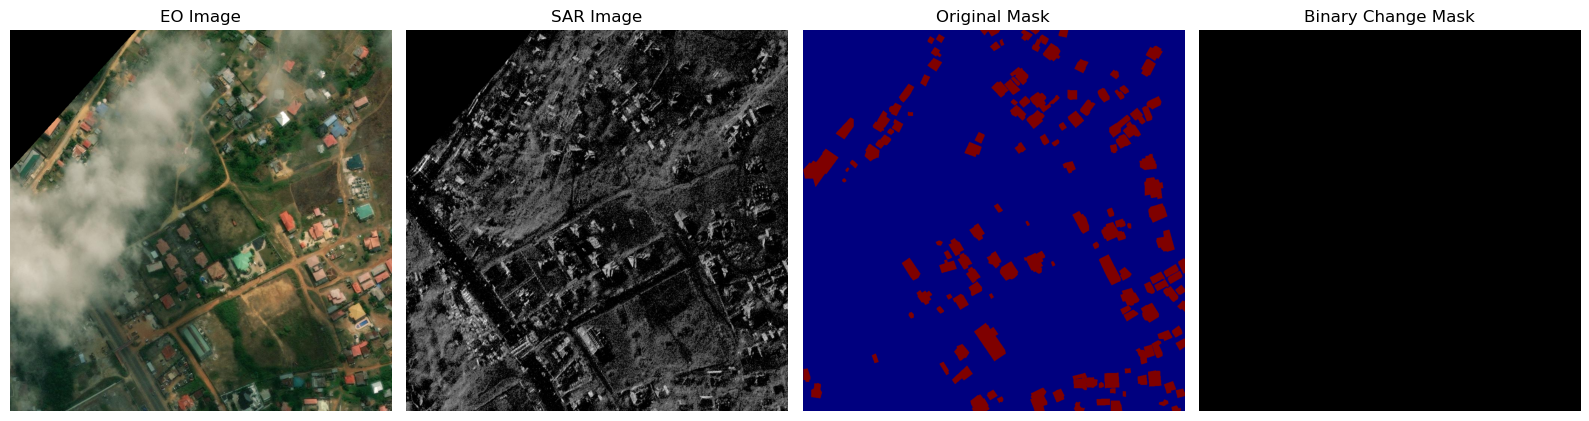

Exploring Dataset:   0%|                                           | 2/2781 [00:00<18:49,  2.46it/s]

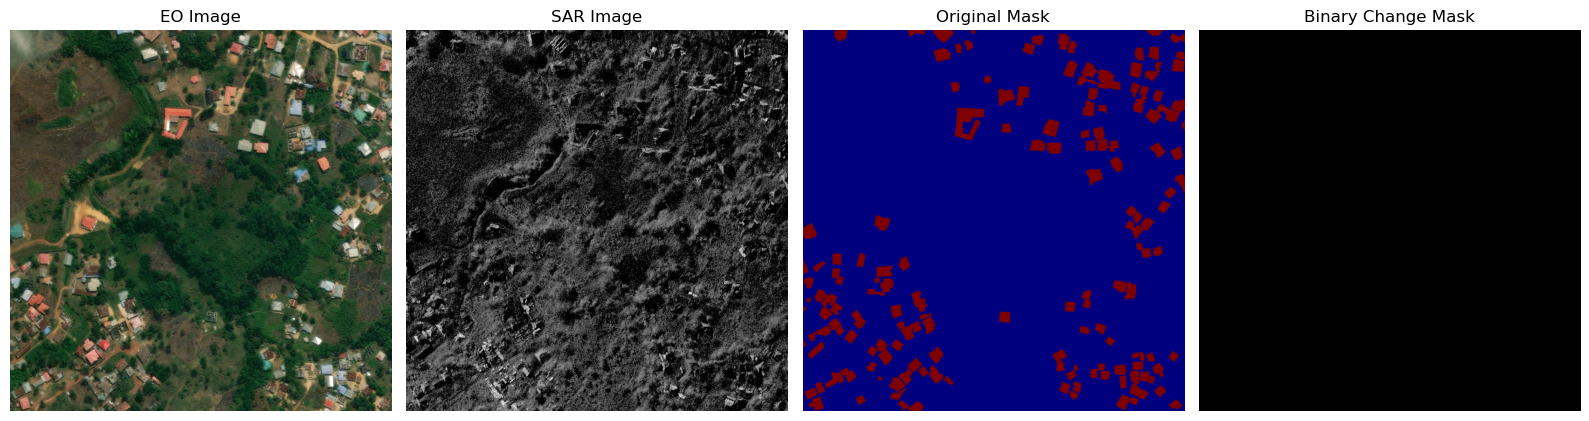

Exploring Dataset:   0%|                                           | 3/2781 [00:01<19:46,  2.34it/s]

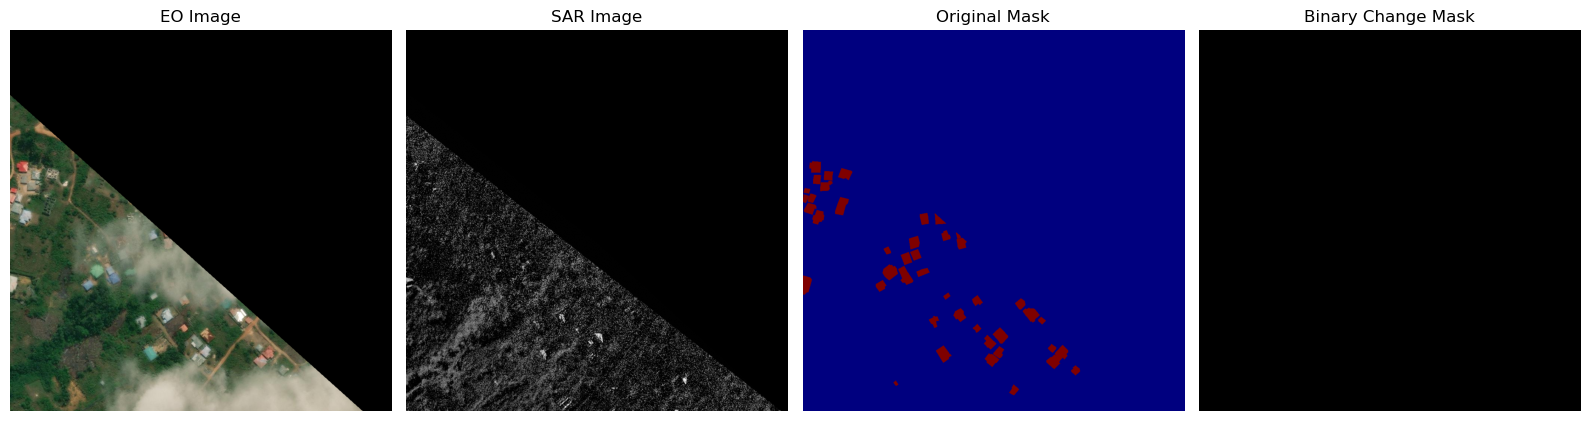

Exploring Dataset:   0%|                                           | 4/2781 [00:01<19:51,  2.33it/s]

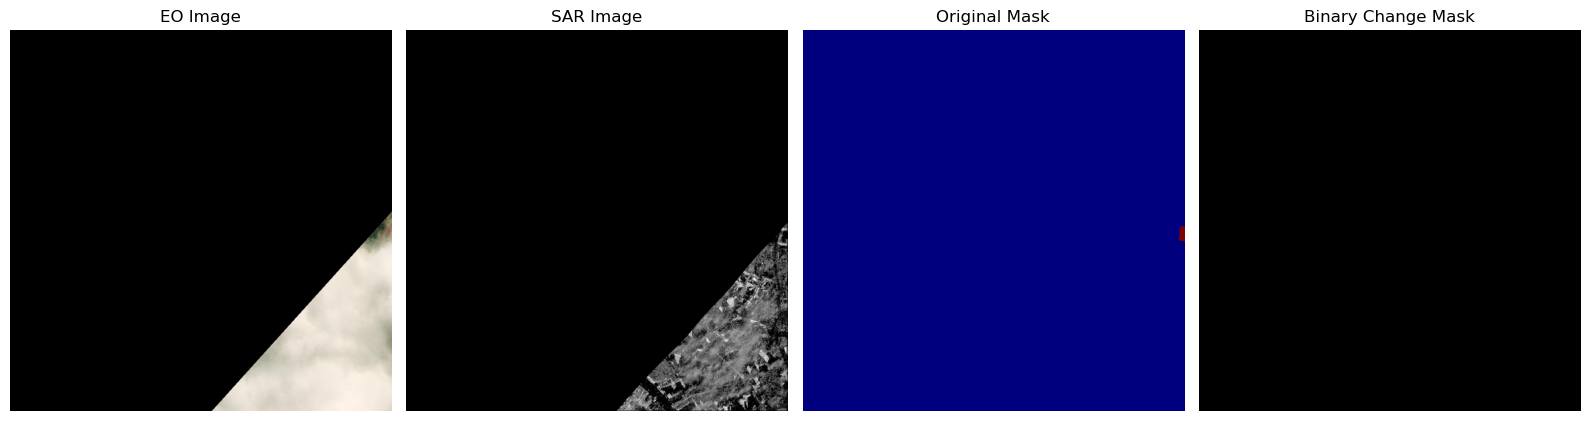

Exploring Dataset: 100%|████████████████████████████████████████| 2781/2781 [00:42<00:00, 65.36it/s]



📊 DATASET STATISTICS
EO Mean             : 81.0526
EO Std              : 47.5750
SAR Mean            : 57.4259
SAR Std             : 37.3503
Total Pixels        : 2,916,089,856
Change Pixels       : 45,769,150
No-Change Pixels    : 2,870,320,706
Change Ratio        : 0.0157
No-Change Ratio     : 0.9843


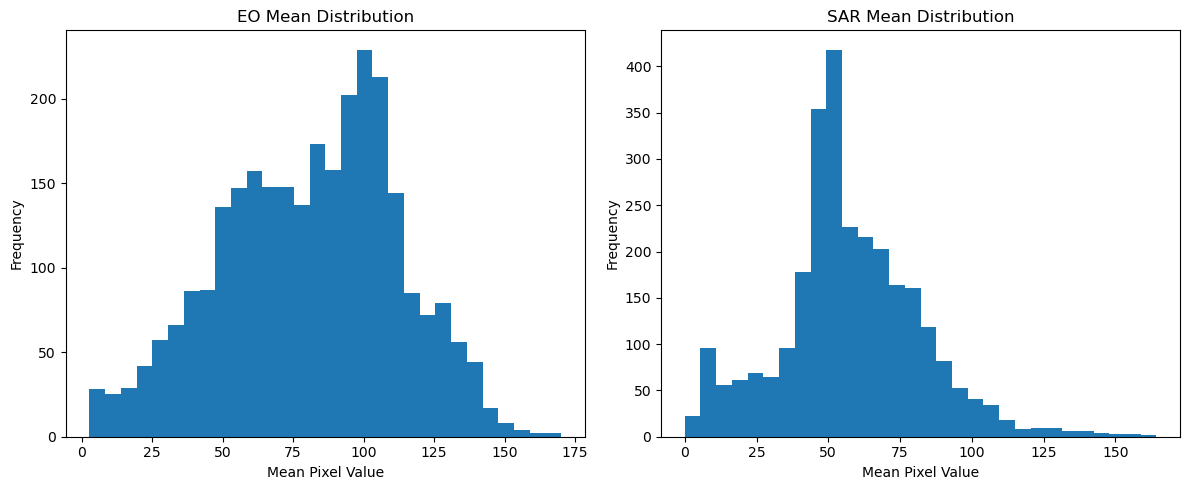

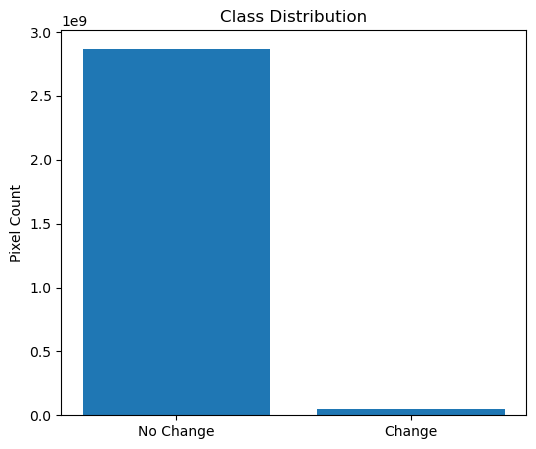


✅ Visualizations saved to: outputs/data_exploration

Generated Files:
- sample_0.png to sample_4.png
- histograms.png
- class_distribution.png


In [3]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================================================
# CONFIGURATION
# =========================================================

PRE_DIR = "/home/shruti/GalaxEye/train/pre-event"
POST_DIR = "/home/shruti/GalaxEye/train/post-event"
MASK_DIR = "/home/shruti/GalaxEye/train/target"

SAVE_DIR = "outputs/data_exploration"

os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================================
# LOAD FILES
# =========================================================

files = sorted(os.listdir(PRE_DIR))

print("=" * 60)
print(f"Total samples found: {len(files)}")
print("=" * 60)

# =========================================================
# STATISTICS STORAGE
# =========================================================

eo_means = []
eo_stds = []

sar_means = []
sar_stds = []

change_pixels = 0
nochange_pixels = 0
total_pixels = 0

# =========================================================
# DATA EXPLORATION LOOP
# =========================================================

for i, filename in enumerate(tqdm(files, desc="Exploring Dataset")):

    # -----------------------------------------------------
    # LOAD EO IMAGE (PRE-EVENT)
    # -----------------------------------------------------

    pre_path = os.path.join(PRE_DIR, filename)

    with rasterio.open(pre_path) as src:
        eo = src.read().transpose(1, 2, 0).astype(np.float32)

    # -----------------------------------------------------
    # LOAD SAR IMAGE (POST-EVENT)
    # -----------------------------------------------------

    post_path = os.path.join(POST_DIR, filename)

    with rasterio.open(post_path) as src:
        sar = src.read(1).astype(np.float32)

    # -----------------------------------------------------
    # LOAD MASK
    # -----------------------------------------------------

    mask_path = os.path.join(MASK_DIR, filename)

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    # -----------------------------------------------------
    # CORRECT LABEL REMAPPING
    #
    # 0 -> Background     -> No Change
    # 1 -> Intact         -> No Change
    # 2 -> Damaged        -> Change
    # 3 -> Destroyed      -> Change
    # -----------------------------------------------------

    binary_mask = np.where(mask >= 2, 1, 0).astype(np.uint8)

    # =====================================================
    # STATISTICS
    # =====================================================

    eo_means.append(eo.mean())
    eo_stds.append(eo.std())

    sar_means.append(sar.mean())
    sar_stds.append(sar.std())

    total_pixels += binary_mask.size
    change_pixels += (binary_mask == 1).sum()
    nochange_pixels += (binary_mask == 0).sum()

    # =====================================================
    # SAVE SAMPLE VISUALIZATIONS
    # =====================================================

    if i < 5:

        # Normalize EO for display
        eo_vis = (eo - eo.min()) / (eo.max() - eo.min() + 1e-8)

        # Normalize SAR for display
        sar_vis = (sar - sar.min()) / (sar.max() - sar.min() + 1e-8)

        # Create figure
        fig, axs = plt.subplots(1, 4, figsize=(16, 5))

        # EO
        axs[0].imshow(eo_vis)
        axs[0].set_title("EO Image")

        # SAR
        axs[1].imshow(sar_vis, cmap="gray")
        axs[1].set_title("SAR Image")

        # Original Mask
        axs[2].imshow(mask, cmap="jet")
        axs[2].set_title("Original Mask")

        # Binary Mask
        axs[3].imshow(binary_mask, cmap="gray")
        axs[3].set_title("Binary Change Mask")

        for ax in axs:
            ax.axis("off")

        plt.tight_layout()

        save_path = os.path.join(SAVE_DIR, f"sample_{i}.png")
        #plt.savefig(save_path, dpi=300)

        plt.show()

# =========================================================
# FINAL STATISTICS
# =========================================================

change_ratio = change_pixels / total_pixels
nochange_ratio = nochange_pixels / total_pixels

print("\n" + "=" * 60)
print("📊 DATASET STATISTICS")
print("=" * 60)

print(f"EO Mean             : {np.mean(eo_means):.4f}")
print(f"EO Std              : {np.mean(eo_stds):.4f}")

print(f"SAR Mean            : {np.mean(sar_means):.4f}")
print(f"SAR Std             : {np.mean(sar_stds):.4f}")

print(f"Total Pixels        : {total_pixels:,}")

print(f"Change Pixels       : {change_pixels:,}")
print(f"No-Change Pixels    : {nochange_pixels:,}")

print(f"Change Ratio        : {change_ratio:.4f}")
print(f"No-Change Ratio     : {nochange_ratio:.4f}")

# =========================================================
# HISTOGRAMS
# =========================================================

plt.figure(figsize=(12, 5))

# EO histogram
plt.subplot(1, 2, 1)
plt.hist(eo_means, bins=30)
plt.title("EO Mean Distribution")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency")

# SAR histogram
plt.subplot(1, 2, 2)
plt.hist(sar_means, bins=30)
plt.title("SAR Mean Distribution")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency")

hist_path = os.path.join(SAVE_DIR, "histograms.png")

plt.tight_layout()
#plt.savefig(hist_path, dpi=300)
plt.show()

# =========================================================
# CLASS DISTRIBUTION BAR PLOT
# =========================================================

plt.figure(figsize=(6, 5))

classes = ["No Change", "Change"]
values = [nochange_pixels, change_pixels]

plt.bar(classes, values)

plt.title("Class Distribution")
plt.ylabel("Pixel Count")

class_dist_path = os.path.join(SAVE_DIR, "class_distribution.png")

#plt.savefig(class_dist_path, dpi=300)
plt.show()

# =========================================================
# COMPLETED
# =========================================================

print("\n" + "=" * 60)
print(f"✅ Visualizations saved to: {SAVE_DIR}")
print("=" * 60)

print("\nGenerated Files:")
print("- sample_0.png to sample_4.png")
print("- histograms.png")
print("- class_distribution.png")